In [1]:
import sys
from pathlib import Path
from typing import Iterable

notebook_dir = Path().resolve()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root))


In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

sns.set_style('dark')

from parsing import parse_raw_csv
from preprocessing import Preprocessor
from units import unit_dimension_report
from resources.config_experiment import *
from resources.config import *

DATA_PATH = "../data/grinding.csv"
RANDOM_STATE = 42

## Data preprocessing

In [3]:
df_clean = parse_raw_csv(DATA_PATH, out_path="../data/grinding_clean.csv")
df_clean.head()

Articles detected:  4058
Unique article ids: 562
Saved cleaned dataset to: ../data/grinding_clean.csv


,ids,doi,Type of Synthesis,Formula,API,Coformer,Part of Ratio API,Part of Ratio Coformer,Amount of API,Amount of Coformer,...,Frequency Unit,Mixing Time,Mixing Time Unit,Mixing Temperature,Mixing Temperature Unit,Drying Time,Drying Time Unit,Drying Temperature,Drying Temperature Unit,Temperature of Drying (numeric)
0,id0007,10.3390/pharmaceutics13040546,liquid-assisted grinding,MTZ-EG,metronidazole,ethyl gallate,0.15,0.15,25.7,29.7,...,hz,30,min,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
1,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,1,1,NOT_DETECTED,NOT_DETECTED,...,hz,15,min,30,c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
2,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,1,2,NOT_DETECTED,NOT_DETECTED,...,hz,15,min,30,c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
3,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,2,1,NOT_DETECTED,NOT_DETECTED,...,hz,15,min,30,c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
4,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,PA-HQ,piracetam,hydroquinone,1,1,NOT_DETECTED,NOT_DETECTED,...,hz,15,min,30,c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED


In [4]:
preprocessor = Preprocessor(method="grinding")
df_model = preprocessor.transform(df_clean, out_path="../data/grinding_normalized.csv", verbose=False)


In [5]:
coverage = preprocessor.coverage_report(df_clean, df_model)
coverage

,column,n_observed,n_unmapped
0,Type of Synthesis,4058,1235
1,Solvent,2559,30
2,Second Solvent,57,0
3,Third Solvent,6,0
4,Mixing Apparatus,3164,75
5,Part of Ratio API,3646,0
6,Part of Ratio Coformer,3632,2
7,Amount of API,1603,1
8,Amount of Coformer,1378,1
9,Amount of Solvent,1461,77


In [6]:
report = preprocessor.preprocessing_report()
report

,column,n_observed_start,n_missing_unit_norm,n_missing_cat_map,n_missing_num_bin,n_observed_final
12,Type of Synthesis,4058,0,0,0,4058
0,Part of Ratio API,3646,0,0,0,3646
1,Part of Ratio Coformer,3632,2,0,0,3630
16,Mixing Apparatus,3164,0,0,0,3164
8,Mixing Time,2859,0,0,0,2859
13,Solvent,2559,0,0,0,2559
2,Amount of API,1603,1,0,0,1602
7,Mixing Frequency,1599,12,0,0,1587
4,Amount of Solvent,1461,77,0,0,1384
3,Amount of Coformer,1378,1,0,0,1377


## Statistics

In [7]:
def missing_summary(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    columns = list(columns)
    n_total = len(df)
    rows = []
    
    for column in columns:
        n_missing = int((df[column] == MISSING_MARKER).sum())
        rows.append(
            {
                "column": column,
                "n_observed": n_total - n_missing,
                "n_missing": n_missing,
                "fill_rate_%": round(100 * (n_total - n_missing) / n_total, 2) if n_total else 0.0,
            }
        )
    return pd.DataFrame(rows).sort_values("fill_rate_%", ascending=False).reset_index(drop=True)

In [8]:
missing_summary(df_model, VARIABLE_COLUMNS)

,column,n_observed,n_missing,fill_rate_%
0,Type of Synthesis,4058,0,100.00
1,Part of Ratio API,3646,412,89.85
2,Part of Ratio Coformer,3630,428,89.45
3,Mixing Apparatus,3164,894,77.97
4,Mixing Time,2859,1199,70.45
5,Solvent,2559,1499,63.06
6,Amount of API,1602,2456,39.48
7,Mixing Frequency,1587,2471,39.11
8,Amount of Solvent,1384,2674,34.11
9,Amount of Coformer,1377,2681,33.93


In [9]:
unit_report = unit_dimension_report(df_model)
unit_report

,column,canonical_unit,raw_value,count,category
0,Amount Unit,mg,NOT_DETECTED,2306,no data
1,Amount Unit,mg,mg,1220,canonical
2,Amount Unit,mg,mmol,349,another dimension
3,Amount Unit,mg,g,164,same dimension
4,Amount Unit,mg,mol,15,another dimension
5,Amount Unit,mg,equivalent,2,unknown
6,Amount Unit,mg,μl,2,another dimension
13,Drying Temperature Unit,c,NOT_DETECTED,4039,no data
14,Drying Temperature Unit,c,c,19,canonical
17,Drying Time Unit,min,NOT_DETECTED,3991,no data


## Distributions

In [21]:
BIN_RE = re.compile(r"^\[(-?[\d.]+),\s*(-?[\d.]+|inf)\)$")
COLORS = plt.cm.magma(np.linspace(0.2, 1, 20))

def plot_distributions(df, columns, top_k=20, n_cols=2, subplot_height=4):
    df = df.copy().replace(MISSING_MARKER, pd.NA)
    columns = list(columns)
    n_rows = -(-len(columns) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, subplot_height * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for i, (ax, col) in enumerate(zip(axes, columns)):
        series = df[col]
        n_total, n_missing = len(series), int(series.isna().sum())
        color = COLORS[i % len(COLORS)]
        counts = series.value_counts()
        values = series.dropna().unique().tolist()
        is_binned = bool(values) and all(BIN_RE.match(str(v)) for v in values)

        if is_binned:
            labels = sorted(values, key=lambda v: float(BIN_RE.match(str(v)).group(1)))
            heights = [int(counts.get(v, 0)) for v in labels]
        else:
            labels = counts.index.tolist()
            heights = list(counts.values)
            if len(labels) > top_k:
                rest = sum(heights[top_k:])
                labels = labels[:top_k] + [f"another ({len(labels) - top_k})"]
                heights = heights[:top_k] + [rest]

        ax.bar(range(len(labels)), heights, color=color)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)

        fill_rate = 100 * (n_total - n_missing) / n_total if n_total else 0
        ax.set_title(f"{col}\nfill {fill_rate:.0f}% (missing: {n_missing}, total: {n_total})", fontsize=9)
        ax.tick_params(labelsize=7)

    for ax in axes[len(columns):]:
        ax.axis("off")

    fig.tight_layout()
    return fig, axes


def plot_kde(df, columns, n_cols=2, subplot_height=3.2):
    df = df.copy().replace(MISSING_MARKER, pd.NA)
    columns = list(columns)
    n_rows = -(-len(columns) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.5 * n_cols, subplot_height * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for i, (ax, col) in enumerate(zip(axes, columns)):
        values = pd.to_numeric(df[col], errors="coerce").dropna()
        n_total, n_observed = len(df), len(values)
        color = COLORS[i % len(COLORS)]

        if n_observed < 2 or values.nunique() < 2:
            ax.text(0.5, 0.5, "no data for KDE", ha="center", va="center", fontsize=8)
        else:
            kde = gaussian_kde(values)
            x = np.linspace(values.min(), values.max(), 200)
            ax.plot(x, kde(x), color=color, linewidth=2)
            ax.fill_between(x, kde(x), color=color, alpha=0.3)
            ax.scatter(values, np.zeros_like(values), color=color, marker="|", s=40)

        fill_rate = 100 * n_observed / n_total if n_total else 0
        ax.set_title(f"{col}\nfill {fill_rate:.0f}% (missing: {n_total - n_observed}, total: {n_total})", fontsize=9)
        ax.tick_params(labelsize=7)

    for ax in axes[len(columns):]:
        ax.axis("off")

    fig.tight_layout()
    return fig, axes

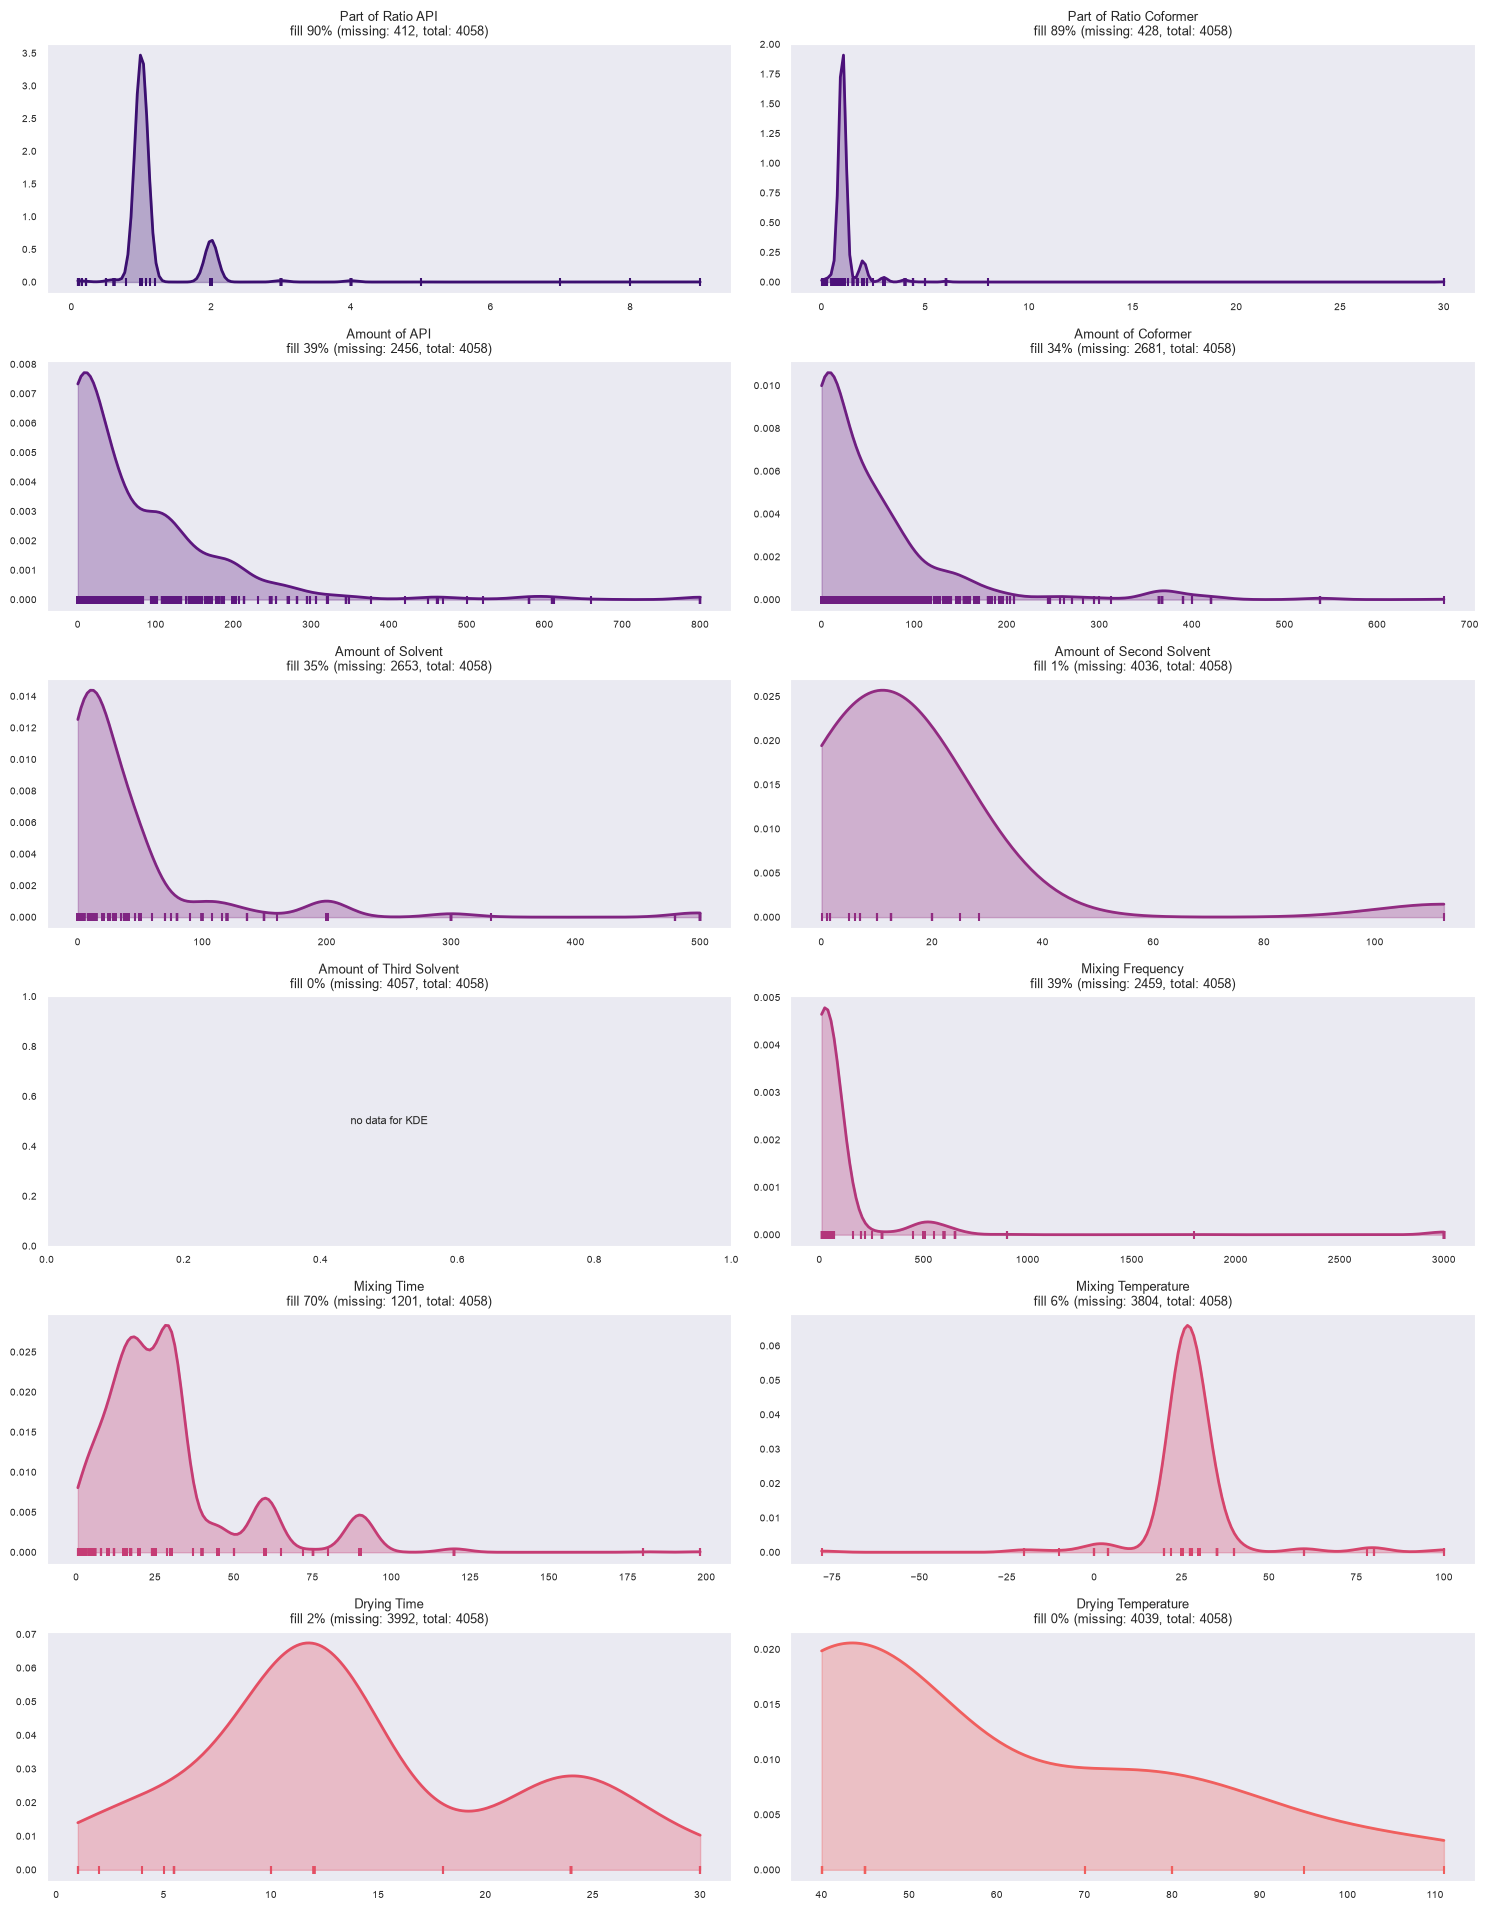

In [22]:
fig, axes = plot_kde(df_clean, NUMERIC_COLUMNS)

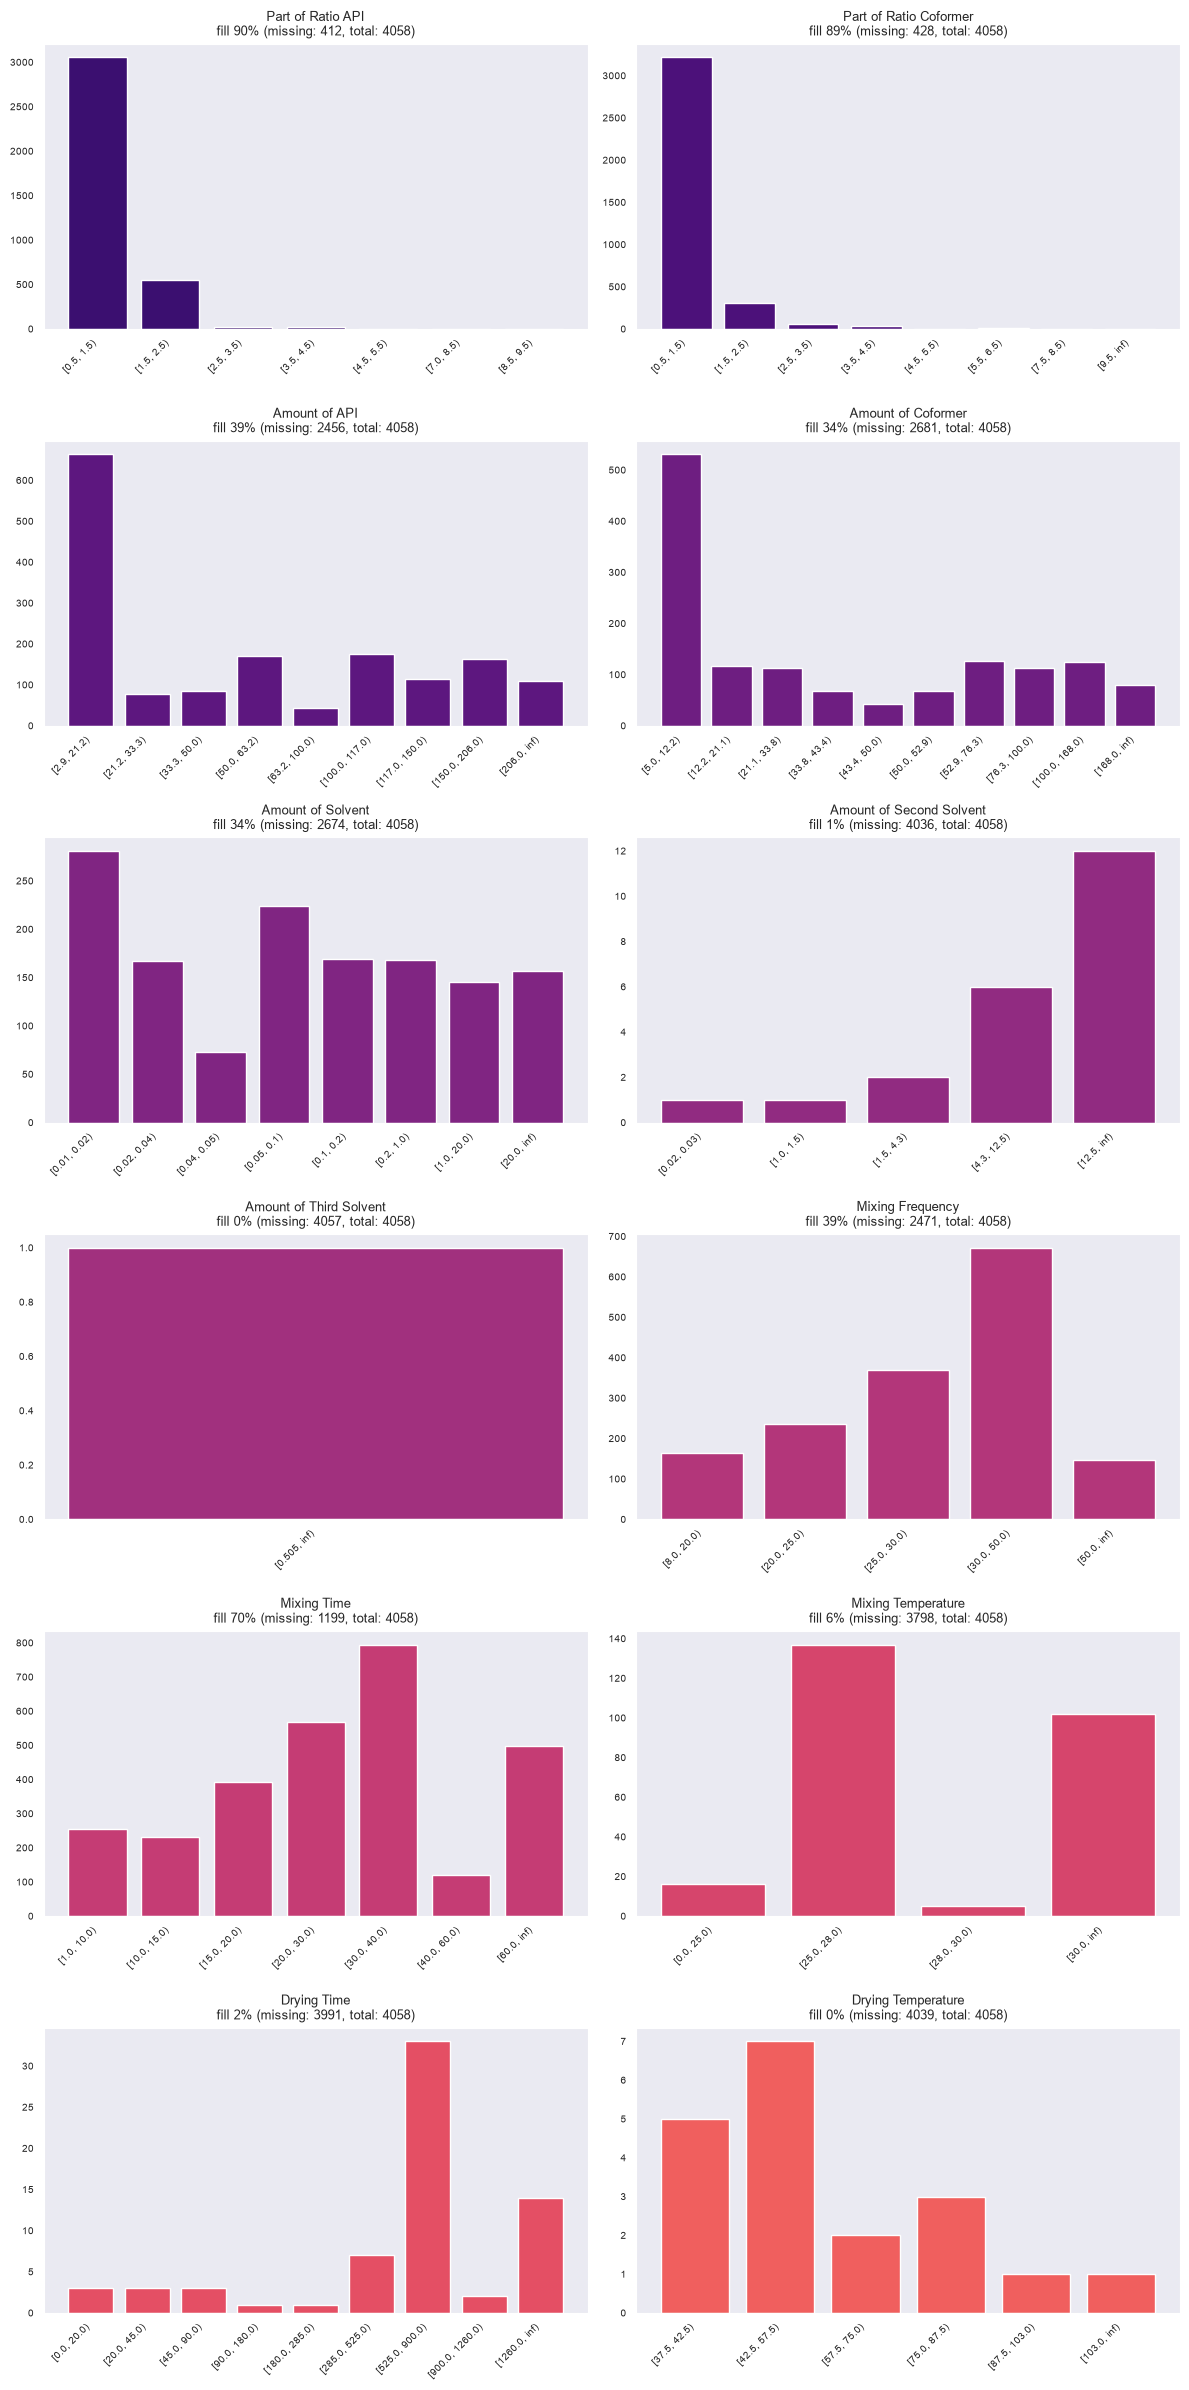

In [23]:
fig, axes = plot_distributions(df_model, NUMERIC_COLUMNS)

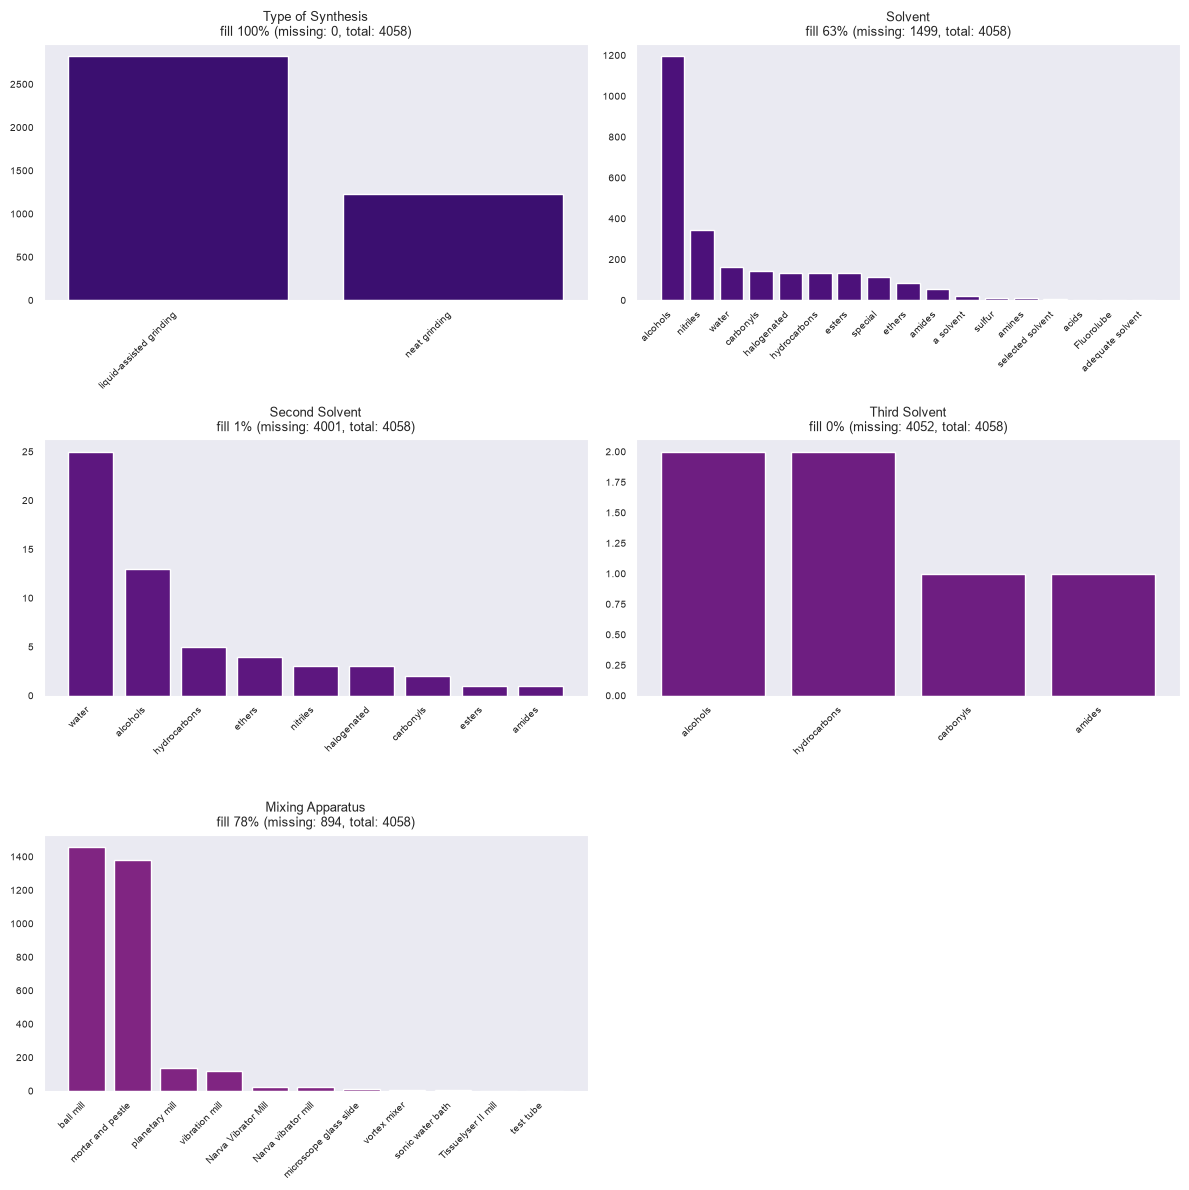

In [24]:
fig, axes = plot_distributions(df_model, CATEGORICAL_COLUMNS
)